In [1]:
import numpy as np
import pandas as pd
import locan as lc
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

import os
import sys
path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(splitted[0]+os.sep, splitted[1], splitted[2], splitted[3])
src_path = os.path.join(user_independent, 'GitHub', 'Photoswitching')
sys.path.append(src_path)

import src.miscellaneous as mi
import src.figure as fi
import src.blinking as bl
import src.emissions as em

%load_ext autoreload
%autoreload 2

In [2]:
def get_files_in_path(directory):
    files = []
    # Walk through the directory
    for root, _, filenames in os.walk(directory):
        # Append full path of each file to the list
        for filename in filenames:
            files.append(os.path.join(root, filename))
    return files

c:\Users\ebert\miniconda3\envs\markovmodels\lib\site-packages\numpy\lib\histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
c:\Users\ebert\miniconda3\envs\markovmodels\lib\site-packages\numpy\lib\histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
c:\Users\ebert\miniconda3\envs\markovmodels\lib\site-packages\numpy\lib\histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
c:\Users\ebert\miniconda3\envs\markovmodels\lib\site-packages\numpy\lib\histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


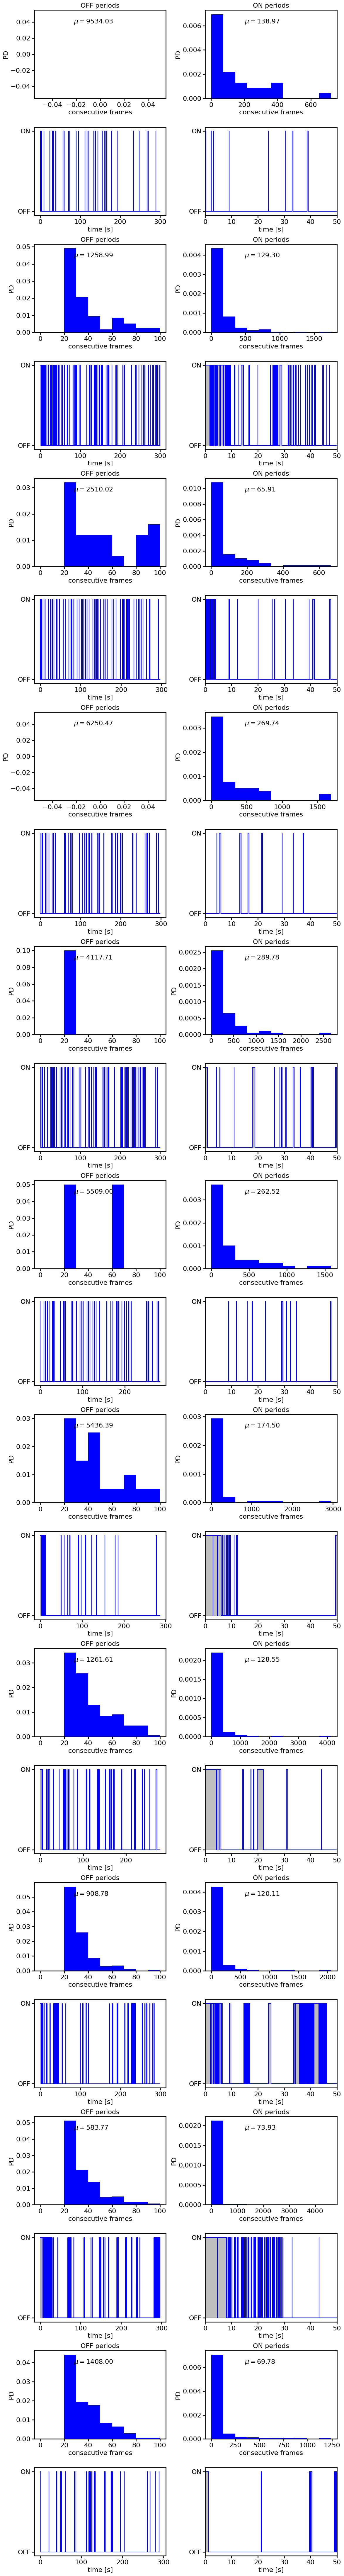

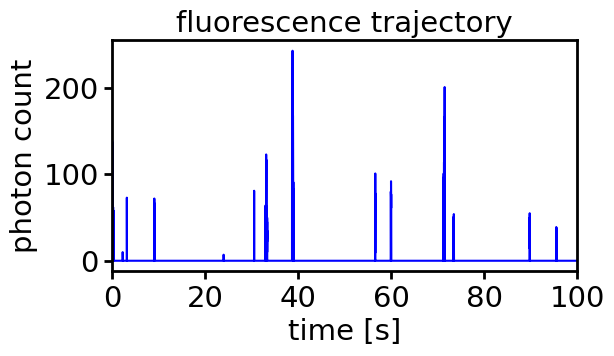

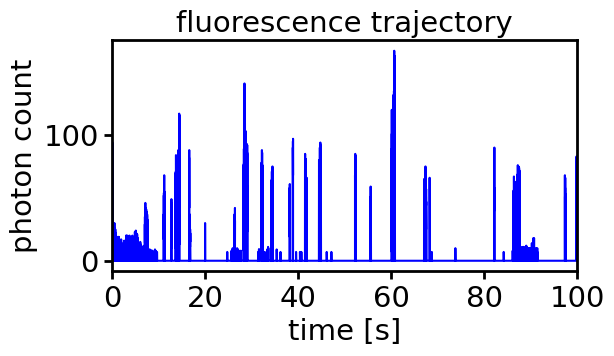

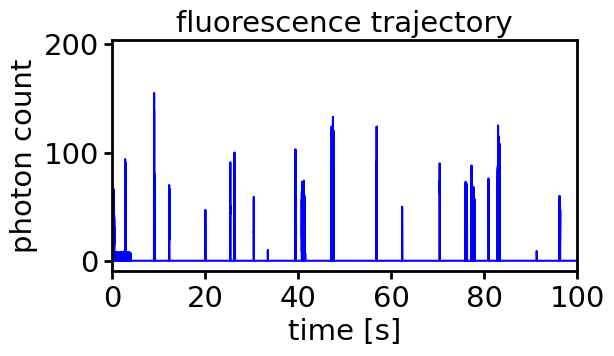

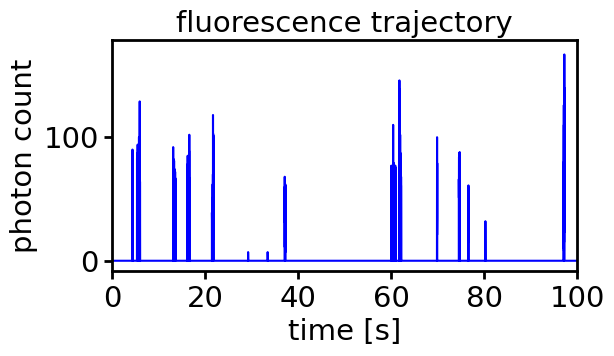

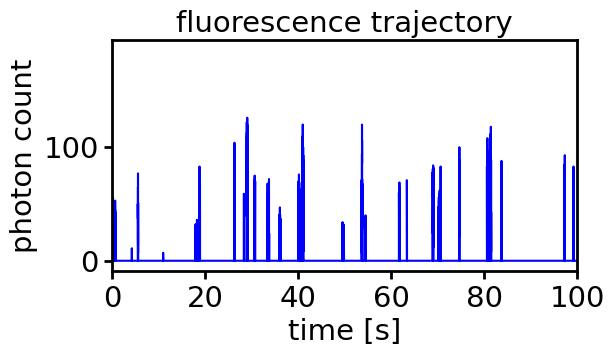

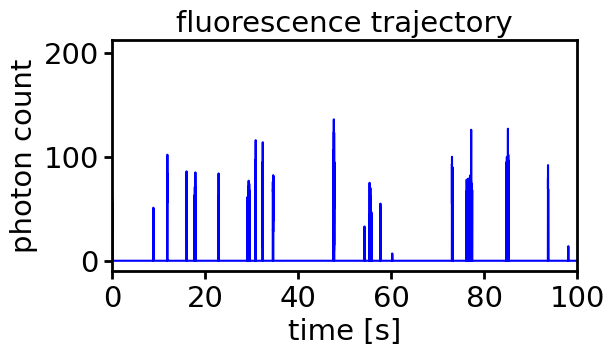

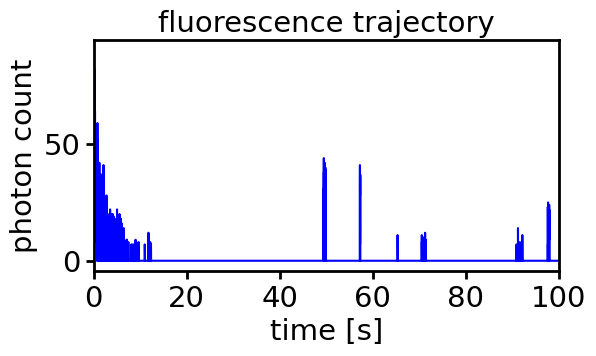

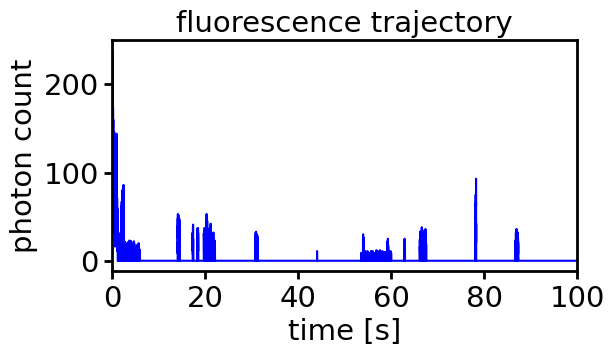

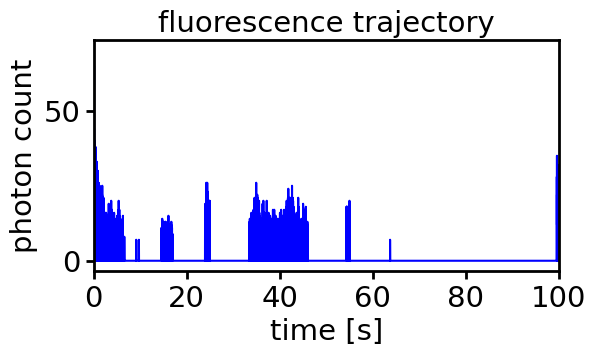

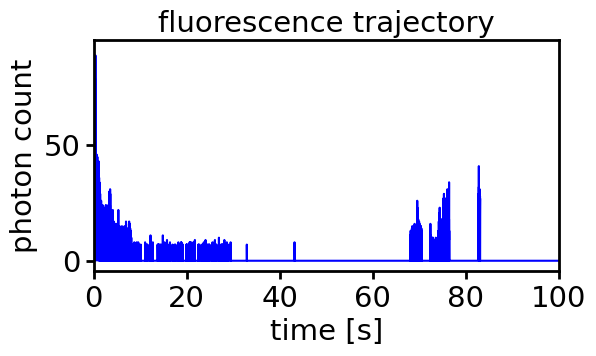

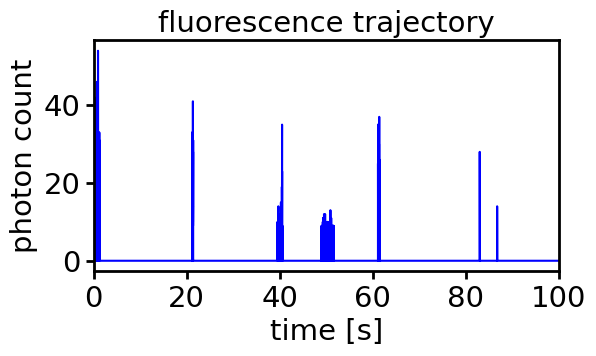

In [3]:
memory = 20
path = r"C:\Users\ebert\OneDrive - Universität Würzburg\origami\9nm-Origami_TimeTrace"
files = get_files_in_path(path)
nrows = len(files)*2
axes = fi.universal_figure(nrows=nrows, ncols=2, fig_height=nrows*4, fig_width=12)
for i, filepath in enumerate(files):
    data = pd.read_csv(filepath, sep='\t', header=1)
    if 'Intens.[kCnts]' in data.columns:
        data.rename(columns={'Intens.[kCnts]': 'Intens.[Cnts]'}, inplace=True)
        data['Intens.[Cnts]'] = data['Intens.[Cnts]'] * 1000
    data['Intens.[Cnts]'] = data['Intens.[Cnts]'].apply(lambda x: 0 if x < 7 else x)
    emissions = em.Emissions()
    emissions.event_time_series = pd.Series(data['Intens.[Cnts]'].values, data['Time[s]'])
    blinks = bl.Blinking(emissions, memory=memory)
    on_off_times_analytic, on_off_values_analytic = bl.get_analytical_off_statistics(
        off_frames=blinks.off_periods_frames,
        off_periods=blinks.off_periods,
        on_frames=blinks.on_periods_frames,
        frame_time='1ms',
    )
    emissions.plot_time_series(xlim=[0, 100])
    blinks.plot(mode='off_histogram', range=[0, 100], axes=axes[i*2, 0])
    blinks.plot(mode='on_histogram', axes=axes[i*2, 1])
    bl.plot_off_statistics(on_off_times_analytic, on_off_values_analytic, axes=axes[i*2+1, 0])
    axes[i*2+1, 0].fill_between(on_off_times_analytic, on_off_values_analytic, color='gray', alpha=0.5)
    bl.plot_off_statistics(on_off_times_analytic, on_off_values_analytic, axes=axes[i*2+1, 1], xlim=[0, 50])
    axes[i*2+1, 1].fill_between(on_off_times_analytic, on_off_values_analytic, color='gray', alpha=0.5)
figure = mi.get_figure(axes)
figure.tight_layout()